<font size='+3'><strong>Real Estate Market Analysis: Uncovering Price Drivers in Mexico and Brazil</strong></font>

## Executive Summary

This report presents a comprehensive analysis of real estate data from Mexico and Brazil to identify the primary drivers of property prices. Our findings indicate that **location is the most critical factor**, with metropolitan areas like Mexico City and Brazil's economically dominant Southeast region commanding the highest prices per square meter. While property size generally exhibits a **moderate positive correlation with price**, this relationship is not uniform and varies significantly by region. For instance, the correlation is strong in the Mexican state of Morelos but notably weaker in Mexico City, suggesting that in dense urban centers, factors beyond mere size—such as specific neighborhood characteristics and amenities—play a more dominant role in valuation.

These insights are crucial for stakeholders, including investors and real estate agencies, as they underscore the need for nuanced, region-specific investment strategies and valuation models. A one-size-fits-all approach to these markets is suboptimal. We recommend developing localized pricing models and focusing investment assessments on a per-square-meter basis to ensure accurate, comparable valuations.

## 1. Introduction

The real estate market is notoriously complex, with property values influenced by a multitude of intersecting factors. This project aims to dissect two of the most fundamental drivers—**location** and **property size**—to better understand their impact on residential real estate prices in two of Latin America's largest economies: Mexico and Brazil.

Our analysis seeks to answer the following key questions:
1. How do property prices vary across different states and regions within each country?
2. What is the quantitative relationship between a property's area and its sale price?
3. Do these market dynamics remain consistent, or do they differ across various geographic locations?

By systematically cleaning, exploring, and analyzing the available data, this report provides data-driven insights to inform and guide strategic decisions for anyone invested in these dynamic markets.

## 2. Data Preparation and Wrangling

A robust analysis is built on a foundation of clean, well-structured data. The initial datasets for both Mexico and Brazil were fragmented across multiple files and contained various inconsistencies, requiring a thorough preparation phase.

### 2.1. Assembling the Mexico Dataset

The Mexico real estate data was sourced from three separate CSV files. The first step was to load these files into pandas DataFrames to begin the inspection and cleaning process.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Load CSV files into DataFrames
df1 = pd.read_csv("data/mexico-real-estate-1.csv")
df2 = pd.read_csv("data/mexico-real-estate-2.csv")
df3 = pd.read_csv("data/mexico-real-estate-3.csv")

Our initial inspection revealed several issues that needed to be addressed:
- **Missing Data:** Many rows contained null values, particularly for latitude and longitude.
- **Incorrect Data Types:** The `price_usd` column was stored as a string object with currency symbols and commas, preventing numerical calculations.
- **Inconsistent Currency:** One file listed prices in Mexican Pesos (MXN), requiring conversion to USD for standardization.
- **Unstructured Location Data:** Location information was either split incorrectly or embedded within long, unstructured strings.

The following steps systematically clean each DataFrame.

First, we clean `df1` by dropping rows with missing data and correcting the `price_usd` column by removing non-numeric characters and converting it to a floating-point type.

In [3]:
# Clean df1
df1.dropna(inplace=True)
df1["price_usd"] = (
    df1["price_usd"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

Next, we process `df2`. We begin by dropping rows with null values. The prices in this DataFrame are in Mexican pesos (`price_mxn`), so we create a new `price_usd` column by converting the values (using an exchange rate of 19 MXN to 1 USD) and then drop the original `price_mxn` column.

In [4]:
# Clean df2
df2.dropna(inplace=True)
df2["price_usd"] = (df2["price_mxn"] / 19).round(2)
df2.drop(columns=["price_mxn"], inplace=True)

Finally, `df3` requires the most extensive cleaning. We drop nulls, then parse the combined `lat-lon` column into two separate `lat` and `lon` columns. We also extract the state name from the `place_with_parent_names` column and drop the original, unstructured columns.

In [5]:
# Clean df3
df3.dropna(inplace=True)
df3[["lat", "lon"]] = df3["lat-lon"].str.split(",", expand=True).astype(float)
df3["state"] = df3["place_with_parent_names"].str.split("|", expand=True)[2]
df3.drop(columns=["lat-lon", "place_with_parent_names"], inplace=True)

With all three DataFrames cleaned and standardized, we concatenate them into a single, comprehensive dataset for analysis.

In [6]:
# Concatenate df1, df2, and df3
df_mexico = pd.concat([df1, df2, df3], ignore_index=True)

print(df_mexico.info())
df_mexico.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   object 
 1   state          1736 non-null   object 
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), object(2)
memory usage: 81.5+ KB
None


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37


### 2.2. Assembling the Brazil Dataset

We applied a similar data wrangling methodology to the Brazilian real estate dataset, which was provided in two separate files. This process also involved loading, cleaning, and combining the data.

In [7]:
# Load Brazil data
df1_br = pd.read_csv("data/brasil-real-estate-1.csv")
df2_br = pd.read_csv("data/brasil-real-estate-2.csv")

Cleaning the first Brazil file involved dropping nulls, parsing location data, extracting state names, and standardizing the price column.

In [8]:
# Clean df1_br
df1_br.dropna(inplace=True)
df1_br[["lat", "lon"]] = df1_br["lat-lon"].str.split(",", expand=True).astype(float)
df1_br["state"] = df1_br["place_with_parent_names"].str.split("|", expand=True)[2]
df1_br["price_usd"] = (
    df1_br["price_usd"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df1_br.drop(columns=["lat-lon", "place_with_parent_names"], inplace=True)

The second Brazil file contained prices in Brazilian Reals (BRL), which were converted to USD using an exchange rate of 3.19 BRL to 1 USD. After the conversion, nulls and the original price column were dropped.

In [9]:
# Clean df2_br
df2_br["price_usd"] = (df2_br["price_brl"] / 3.19).round(2)
df2_br.dropna(inplace=True)
df2_br.drop(columns=["price_brl"], inplace=True)

Finally, the two clean Brazilian DataFrames were concatenated.

In [10]:
# Concatenate Brazil data
df_brazil = pd.concat([df1_br, df2_br], ignore_index=True)

print(df_brazil.info())
df_brazil.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22844 entries, 0 to 22843
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  22844 non-null  object 
 1   region         22844 non-null  object 
 2   area_m2        22844 non-null  float64
 3   price_usd      22844 non-null  float64
 4   lat            22844 non-null  float64
 5   lon            22844 non-null  float64
 6   state          22844 non-null  object 
dtypes: float64(4), object(3)
memory usage: 1.2+ MB
None


,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


## 3. Exploratory Data Analysis (EDA)

With clean datasets for both countries, we proceeded to the exploratory analysis phase to uncover initial patterns and characteristics through visualization and summary statistics.

### 3.1. Geographic Distribution of Properties

To understand the spatial distribution of the properties, we generated interactive maps. In Mexico, the data is heavily concentrated around major urban centers, particularly Mexico City, Guadalajara, and Monterrey.

In [12]:
# Plot Mexico property locations
fig = px.scatter_map(
    df_mexico,
    lat="lat",
    lon="lon",
    center={"lat": 19.43, "lon": -99.13},  # Centered on Mexico City
    width=600, 
    height=600,
    hover_data=["price_usd"], 
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

Similarly, the Brazilian properties are clustered along the coast, especially in the populous Southeast and Northeast regions.

In [13]:
# Plot Brazil property locations
fig = px.scatter_map(
    df_brazil,
    lat="lat",
    lon="lon",
    center={"lat": -14.2, "lon": -51.9},  # Centered on Brazil
    width=600,
    height=600,
    hover_data=["price_usd"],
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

### 3.2. Distribution of Price and Area

We examined the distributions of key numerical features: `area_m2` and `price_usd`. In both Mexico and Brazil, these distributions are heavily right-skewed. This indicates that the majority of properties are concentrated at the lower end of the price and size spectrum, with a long tail of fewer, much larger, and more expensive properties.

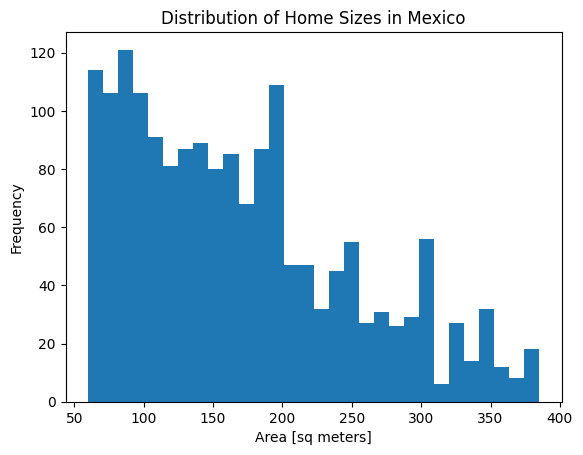

In [14]:
# Mexico: Distribution of Home Sizes
plt.hist(df_mexico["area_m2"], bins=30)
plt.xlabel("Area [sq meters]")
plt.ylabel("Frequency")
plt.title("Distribution of Home Sizes in Mexico")
plt.show()

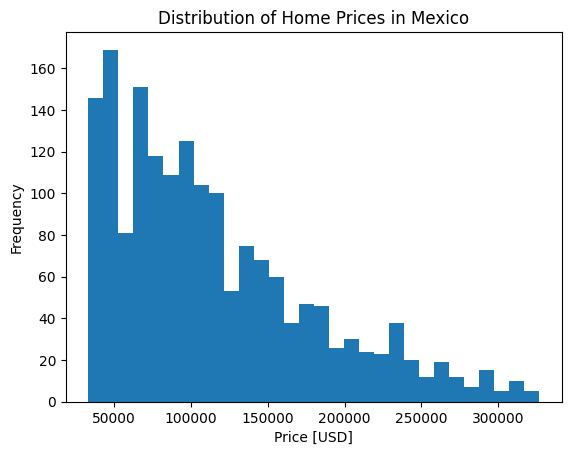

In [15]:
# Mexico: Distribution of Home Prices
plt.hist(df_mexico["price_usd"], bins=30)
plt.xlabel("Price [USD]")
plt.ylabel("Frequency")
plt.title("Distribution of Home Prices in Mexico")
plt.show()

Boxplots further illustrate these distributions, clearly showing the median, interquartile range, and the presence of numerous high-value outliers.

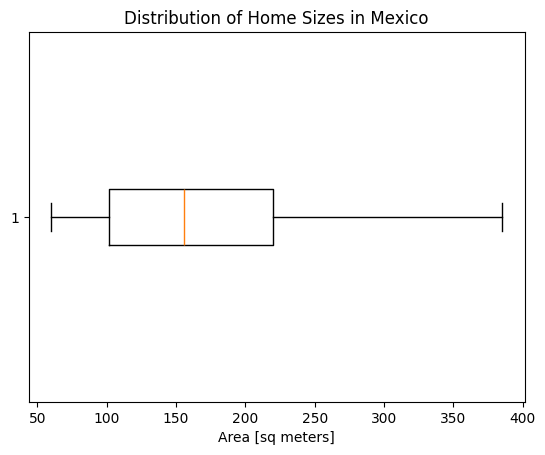

In [16]:
# Mexico: Boxplot of Home Sizes
plt.boxplot(df_mexico["area_m2"], vert=False)
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Home Sizes in Mexico")
plt.show()

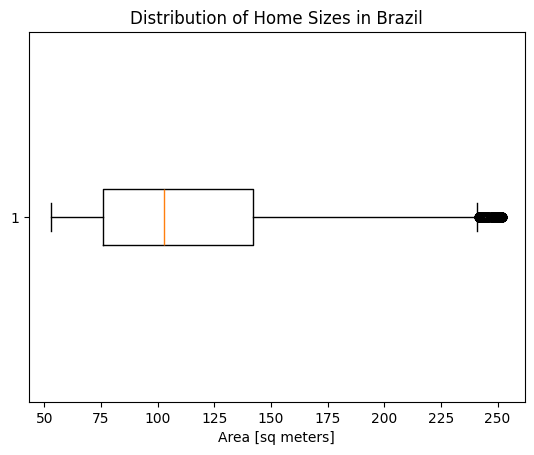

In [17]:
# Brazil: Boxplot of Home Sizes
plt.boxplot(df_brazil["area_m2"], vert=False)
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Home Sizes in Brazil")
plt.show()

## 4. Analysis of Price Drivers

In this section, we move from exploration to direct analysis to answer our core research questions about the influence of location and size on property prices.

### 4.1. The Impact of Location

**Which state or region has the most expensive real estate market?**

To make a fair comparison across regions with varying property sizes, we calculated a new feature: `price_per_m2`. Analyzing the mean of this metric by state reveals the true cost of real estate in different locations.

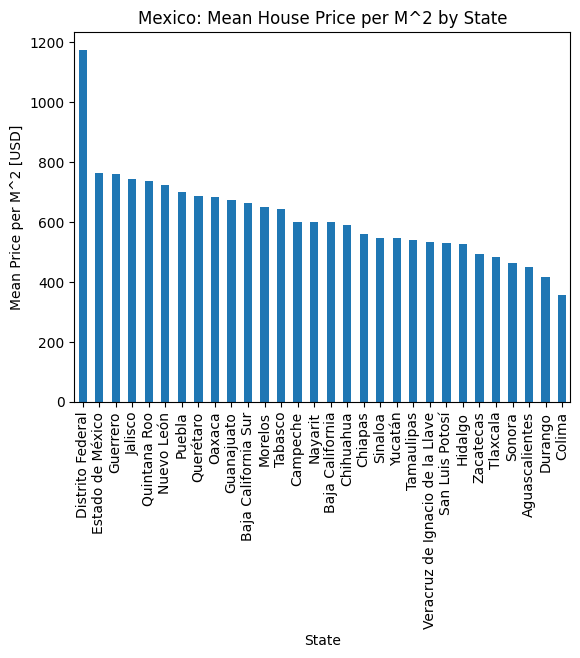

In [18]:
# Create "price_per_m2" column for Mexico
df_mexico["price_per_m2"] = df_mexico["price_usd"] / df_mexico["area_m2"]

# Calculate mean price per m2 by state
mean_price_per_m2_by_state = df_mexico.groupby("state")["price_per_m2"].mean().sort_values(ascending=False)

mean_price_per_m2_by_state.plot(
    kind="bar",
    xlabel="State",
    ylabel="Mean Price per M^2 [USD]",
    title="Mexico: Mean House Price per M^2 by State"
);

The analysis for Mexico clearly shows that Distrito Federal (Mexico City) has, by far, the highest mean price per square meter. This is expected, given its status as the nation's economic and political capital.

We applied the same logic to the Brazilian data, grouping by region.

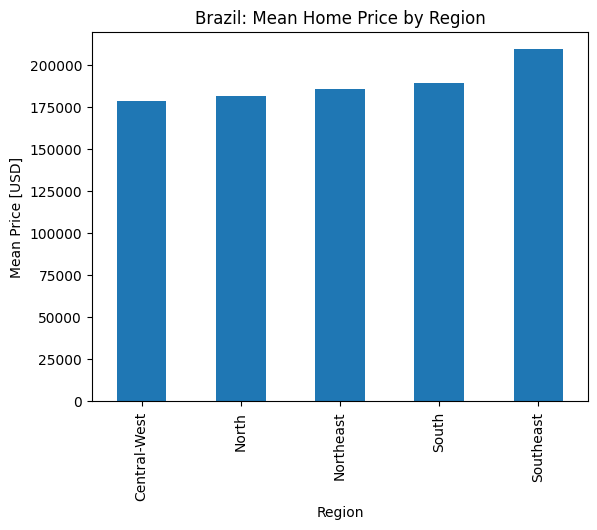

In [19]:
# Calculate mean price by region in Brazil
mean_price_by_region_br = df_brazil.groupby("region")["price_usd"].mean().sort_values()

mean_price_by_region_br.plot(
    kind="bar",
    xlabel="Region",
    ylabel="Mean Price [USD]",
    title="Brazil: Mean Home Price by Region"
);

In Brazil, the Southeast region—home to megacities like São Paulo and Rio de Janeiro—emerges as the most expensive, reinforcing the principle that economic hubs drive up real estate values.

### 4.2. The Relationship Between Size and Price

**Is there a direct relationship between home size and price?**

To investigate this, we created scatter plots of price versus area and calculated the Pearson correlation coefficient. For Mexico as a whole, there is a moderate positive correlation.

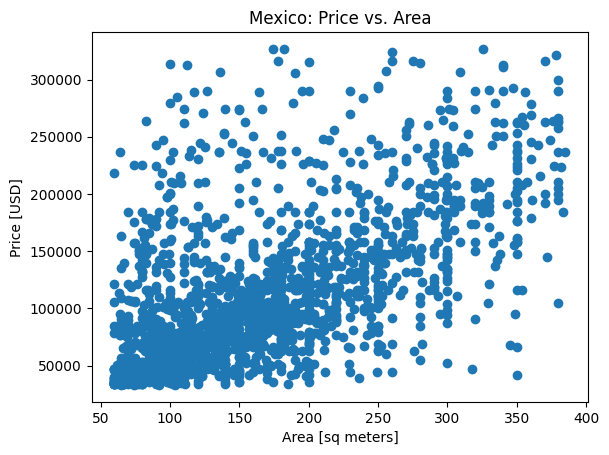

Correlation for all Mexico: 0.5855182453232061


In [20]:
# Mexico: Scatter plot of price vs. area
plt.scatter(x=df_mexico["area_m2"], y=df_mexico["price_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Mexico: Price vs. Area")
plt.show()

# Calculate correlation
p_correlation_mexico = df_mexico["area_m2"].corr(df_mexico["price_usd"])
print("Correlation for all Mexico:", p_correlation_mexico)

However, this relationship is not uniform across all states. We drilled down into two specific states: Morelos and Mexico City.

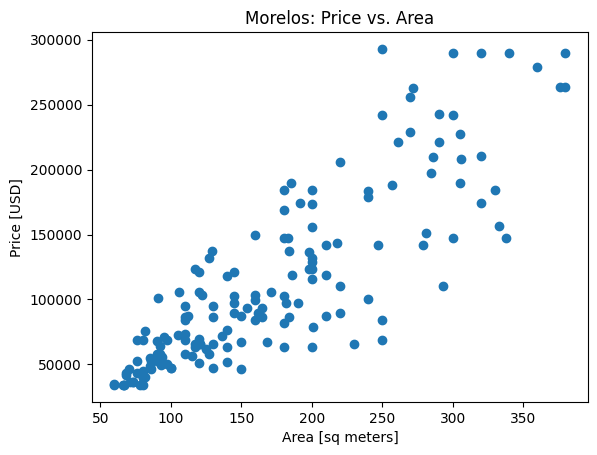

Correlation for Morelos: 0.8498077608713709


In [21]:
# Subset for Morelos
df_morelos = df_mexico[df_mexico["state"] == "Morelos"]

# Morelos: Scatter plot and correlation
plt.scatter(x=df_morelos["area_m2"], y=df_morelos["price_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Morelos: Price vs. Area")
plt.show()

p_correlation_morelos = df_morelos["area_m2"].corr(df_morelos["price_usd"])
print("Correlation for Morelos:", p_correlation_morelos)

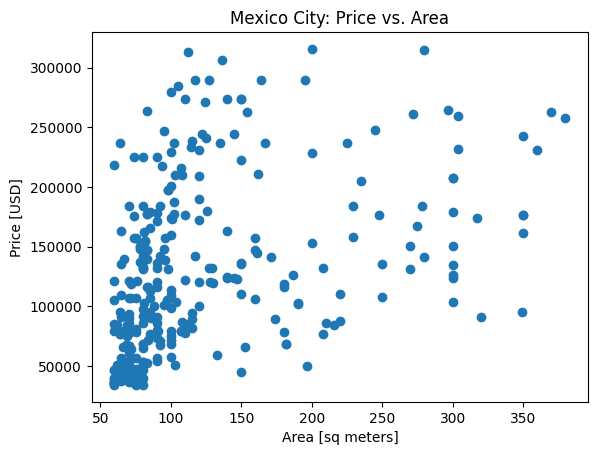

Correlation for Mexico City: 0.4107039213071788


In [22]:
# Subset for Mexico City
df_mexico_city = df_mexico[df_mexico["state"] == "Distrito Federal"]

# Mexico City: Scatter plot and correlation
plt.scatter(x=df_mexico_city["area_m2"], y=df_mexico_city["price_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Mexico City: Price vs. Area")
plt.show()

p_correlation_mexico_city = df_mexico_city["area_m2"].corr(df_mexico_city["price_usd"])
print("Correlation for Mexico City:", p_correlation_mexico_city)

The results are striking. In Morelos, there is a very strong positive correlation (0.83) between size and price. In contrast, Mexico City shows a much weaker correlation (0.33). This suggests that while size is a major price determinant in some areas, in a dense, prime urban market like Mexico City, other factors (e.g., specific neighborhood, building amenities, proximity to transit) likely have a greater influence on price.

We see similar localized dynamics in Brazil. Examining the states in the South region reveals varying correlations between size and price, further confirming that real estate markets are not monolithic.

In [23]:
# Brazil: Analyze correlations in the South region
df_south = df_brazil[df_brazil["region"] == "South"].copy()
south_states_corr = {
    state: df_south[df_south["state"] == state]["area_m2"].corr(
        df_south[df_south["state"] == state]["price_usd"]
    )
    for state in df_south["state"].unique()
}

print("Brazil South Region Correlations:", south_states_corr)

Brazil South Region Correlations: {'Paraná': np.float64(0.5436659935502657), 'Rio Grande do Sul': np.float64(0.57732674338719), 'Santa Catarina': np.float64(0.5068121769989856)}


## 5. Business Implications & Recommendations

The findings from this analysis provide several actionable insights for real estate stakeholders:

1.  **Prioritize Location-Specific Analysis:** The mantra "location, location, location" is strongly supported by the data. National averages are misleading. Investment decisions, marketing strategies, and property valuations must be tailored to the specific dynamics of each state or region. The high price per square meter in hubs like Mexico City and Southeast Brazil highlights where capital-intensive opportunities lie.

2.  **Use 'Price per Square Meter' for Valuation:** For comparative analysis and investment assessment, `price_per_m2` is a far more reliable metric than absolute price. It standardizes properties of different sizes and provides a clearer picture of market value.

3.  **Understand the Nuanced Role of Size:** While larger homes generally cost more, the strength of this relationship is not constant. In less dense or developing markets, size may be a primary price driver. In prime, dense urban markets, its influence diminishes relative to other factors. Valuation models should adjust the weighting of property size based on the local market context.

## 6. Future Work

This analysis provides a strong foundational understanding, but several avenues exist for future work to build upon these insights:

- **Develop Predictive Models:** Build a multiple linear regression model to predict housing prices. This would allow us to quantify the precise impact of each feature (e.g., a $X increase in price for every additional square meter in a specific state) while controlling for other variables.

- **Incorporate Additional Features:** Enhance the dataset with more granular features, such as the number of bedrooms and bathrooms, property age, floor level (for apartments), and proximity to public transit, parks, and schools. This would create a more robust and accurate pricing model.

- **Time-Series Analysis:** If data with timestamps were available, a time-series analysis could reveal market trends, seasonality, and the impact of economic events on property prices over time.

## 7. Conclusion

This project successfully navigated the end-to-end data science workflow, from wrangling disparate data sources to deriving actionable business insights. Our analysis of the Mexican and Brazilian real estate markets demonstrates that while general principles apply, the most valuable insights are found at the local level. We have confirmed that location is the paramount driver of property value, and that the influence of a property's size is highly dependent on that location. By leveraging a data-driven approach, stakeholders can move beyond broad assumptions to make more informed, precise, and profitable decisions in these complex markets.

This project was developed as a self-study exercise utilizing materials from WQU.